# Data Mining and Machine Learning Project
## Falaschi Dario - Masiero Chiara
This is the first of three notebooks used for our Machine Learning course project.
The project is structured as follows:

- **DMML1**: Exploratory Data Analysis, and preprocessing.
- **DMML2**: Model selection and hyperparameter tuning.
- **DMML3**: Final model training, performance evaluation, and Explainable AI analysis.

#1. Imports & load dataset

In [ ]:
# Library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import drive
from sklearn.model_selection import train_test_split
import math
from scipy import stats
from scipy.stats import pearsonr

# ignore the warnings to maintain a clean output
warnings.filterwarnings('ignore')

# set theme for the plots
sns.set_theme(style="whitegrid")

In [ ]:
# Drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/DMML_Project/online_shoppers_intention.csv'

# Dataset Loading
df = pd.read_csv(file_path)
display(df.head())

Mounted at /content/drive


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# Check dimension and data type
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.\n")
df.info()

The dataset contains 12330 rows and 18 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12

# 2. Exploratory Data Analysis (EDA)
## Data Types Analysis
First, we separate the features into numerical and categorical groups. This step is crucial for applying the correct visualization techniques and, later, the appropriate preprocessing steps.

In [ ]:
# Separate features based on their data types
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

# Remove the target variable ('Revenue') from the exploratory lists to avoid confusion
if 'Revenue' in categorical_cols:
    categorical_cols.remove('Revenue')

print(f"Numerical Features ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nCategorical Features ({len(categorical_cols)}):")
print(categorical_cols)

Numerical Features (14):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Categorical Features (3):
['Month', 'VisitorType', 'Weekend']


## Graphical Analysis
We visualize the distribution of each feature individually.
- **Histograms** are used for numerical data.
- **Bar plots** are used for categorical data.

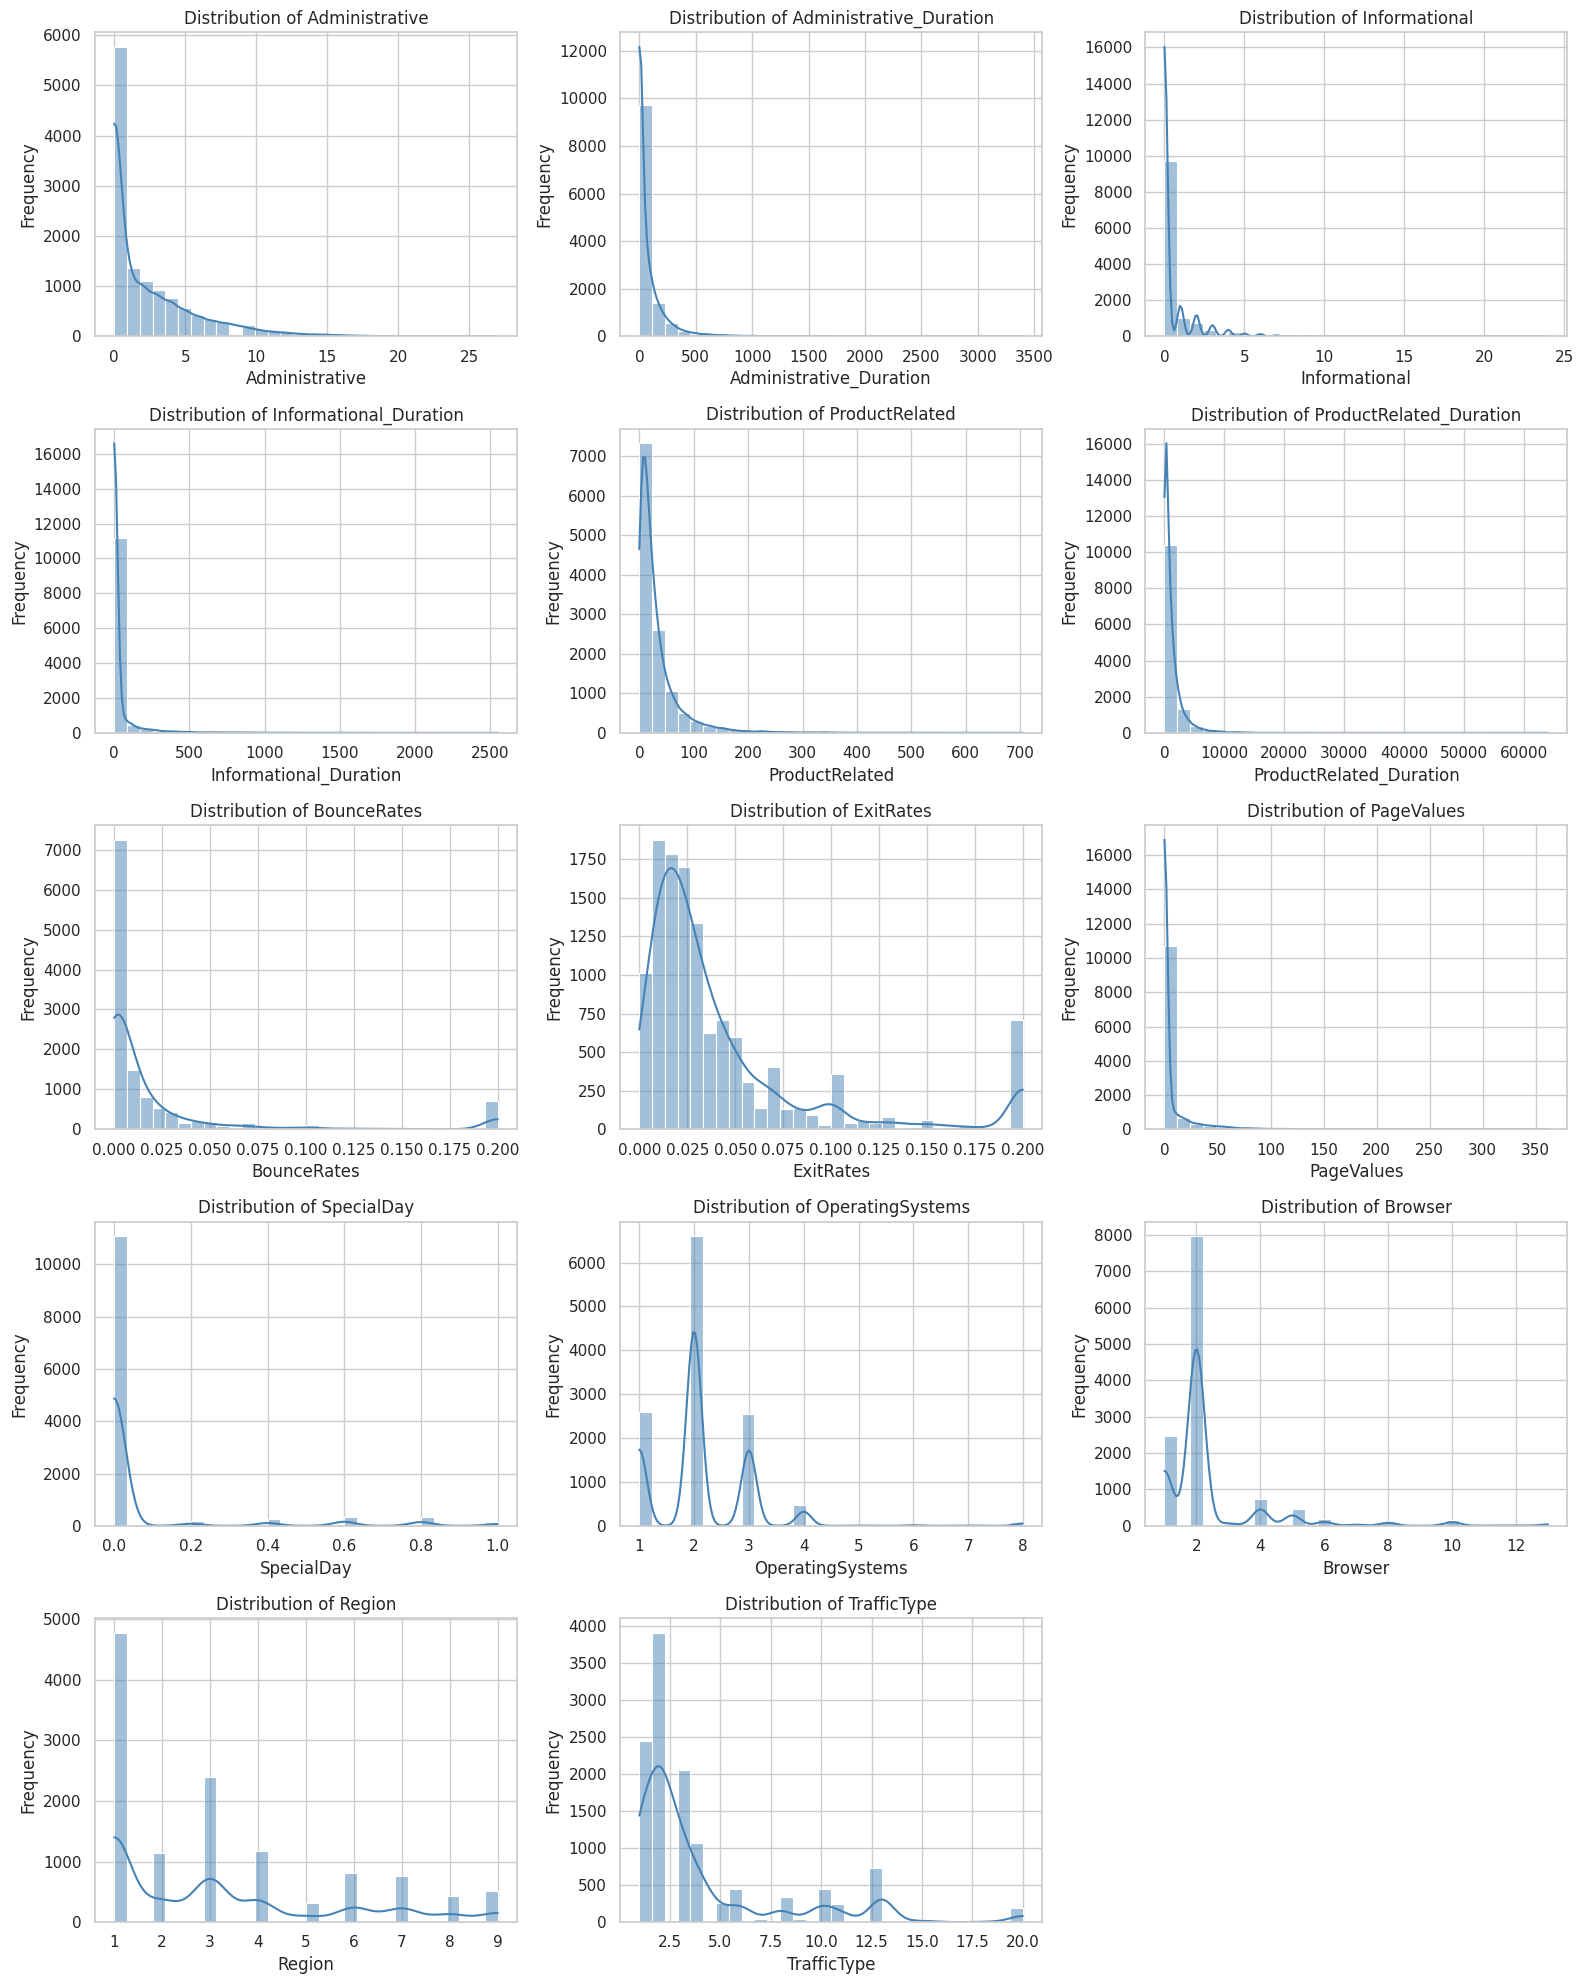

In [ ]:
# 1. Numerical Features Distribution
# Create a grid and insert all the histograms
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

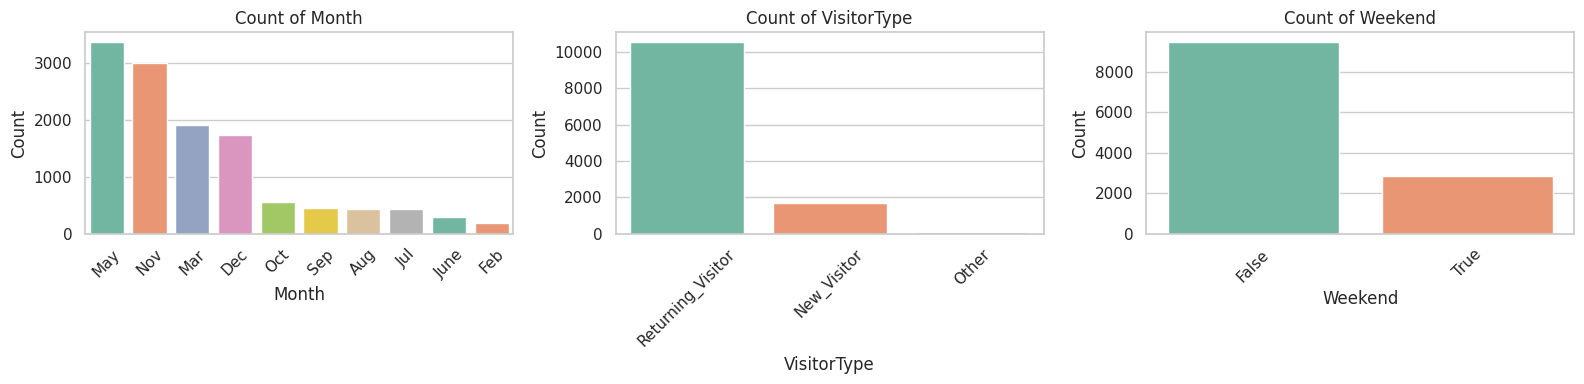

In [ ]:
# 2. Categorical Features Distribution (Bar Plots)
# Create a row and insert all the bar plots
n_rows_cat = math.ceil(len(categorical_cols) / n_cols)

fig, axes_cat = plt.subplots(n_rows_cat, n_cols, figsize=(16, 4 * n_rows_cat))
axes_cat = axes_cat.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes_cat[i], palette='Set2', order=df[col].value_counts().index)
    axes_cat[i].set_title(f'Count of {col}', fontsize=12)
    axes_cat[i].set_ylabel('Count')
    axes_cat[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes_cat)):
    fig.delaxes(axes_cat[j])

plt.tight_layout()
plt.show()

## Target Variable (Revenue) Analysis

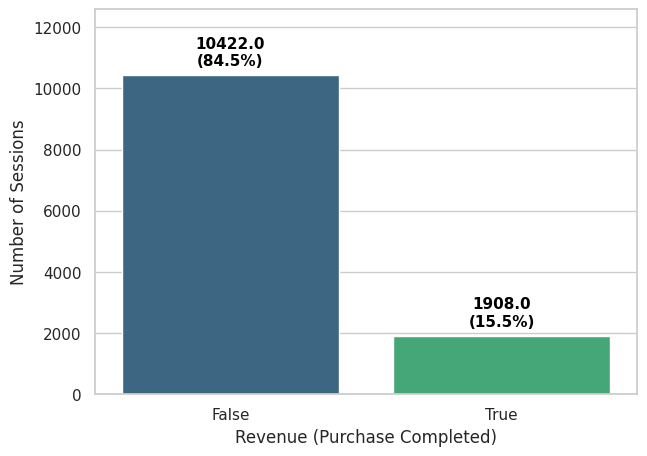

In [ ]:
# Target Analysis: Distribution of the 'Revenue' variable
plt.figure(figsize=(7, 5))

# Create the countplot
ax = sns.countplot(data=df, x='Revenue', palette='viridis')
plt.ylabel('Number of Sessions', fontsize=12)
plt.xlabel('Revenue (Purchase Completed)', fontsize=12)
total_sessions = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_sessions) * 100
    annotation_text = f'{height}\n({percentage:.1f}%)'
    ax.annotate(annotation_text, (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom',
                fontsize=11, color='black', fontweight='bold', xytext=(0, 5), textcoords='offset points')
plt.ylim(0, ax.get_ylim()[1] * 1.15)
plt.show()

# 3. Data Cleaning & Integrity
Before exploring the relationships between variables, we must ensure data quality.

In this section, we will:
1. Check for and remove duplicate rows.
2. Identify missing values and handle them appropriately.
3. Verify data types to ensure they align with the expected formats.

In [ ]:
# 1. Check and remove duplicate rows
initial_rows = df.shape[0]
duplicates_count = df.duplicated().sum()

print(f"Initial number of rows: {initial_rows}")
print(f"Number of duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. Remaining rows: {df.shape[0]}\n")
else:
    print("No duplicates found.\n")

# 2. Check for missing values (NaN)
missing_values = df.isnull().sum()
missing_summary = missing_values[missing_values > 0]

if not missing_summary.empty:
    print("Missing values found in the following columns:")
    print(missing_summary)
else:
    print("No missing values found in the dataset.\n")


Initial number of rows: 12330
Number of duplicate rows found: 125
Duplicates removed. Remaining rows: 12205

No missing values found in the dataset.



In [ ]:
# 3. List of features to investigate if are categorical
suspicious_features = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

print("--- Categorical vs Numerical Analysis ---\n")

for col in suspicious_features:
    unique_values = df[col].nunique()
    value_samples = sorted(df[col].unique())

    print(f"Feature: {col}")
    print(f" - Number of unique values: {unique_values}")
    print(f" - Sample values: {value_samples}")
    print("-" * 40)

--- Categorical vs Numerical Analysis ---

Feature: OperatingSystems
 - Number of unique values: 8
 - Sample values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
----------------------------------------
Feature: Browser
 - Number of unique values: 13
 - Sample values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
----------------------------------------
Feature: Region
 - Number of unique values: 9
 - Sample values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
----------------------------------------
Feature: TrafficType
 - Number of unique values: 20
 - Sample values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.

## Feature Type Conversion

As shown in the output above:`OperatingSystems`, `Browser`, `Region`, and `TrafficType` are encoded as integers.
However, these numbers do not represent continuous or ordinal quantities(e.g., Browser "2" is not inherently greater or twice as large as Browser "1").

Leaving these features as numerical would introduce significant issues:
- Distance-based algorithms (like KNN) would incorrectly assume mathematical distances between these nominal labels.
- In our upcoming pipeline, we plan to use SMOTENC to handle the class imbalance. This algorithm specifically requires categorical features to be defined as such, allowing it to apply the correct mathematical metrics to generate valid synthetic samples.

Therefore, we will convert these specific columns from integers to categorical strings to ensure data integrity.

In [ ]:
# List of numerical features that should be treated as categorical
categorical_id_features = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

# Perform the conversion to string
for col in categorical_id_features:
    df[col] = df[col].astype(str)

# Double check the result to ensure they are now 'object' type
print("New Data Types Summary:")
print(df[categorical_id_features].dtypes)

# Display a summary of these categorical columns
display(df[categorical_id_features].describe())

New Data Types Summary:
OperatingSystems    object
Browser             object
Region              object
TrafficType         object
dtype: object


,OperatingSystems,Browser,Region,TrafficType
count,12205,12205,12205,12205
unique,8,13,9,20
top,2,2,1,2
freq,6541,7883,4714,3911


# 4. Correlation Analysis
We generate a correlation matrix for the numerical features to identify multicollinearity.

High correlation between features (e.g., above 0.8 or below -0.8) indicates redundancy, which might negatively impact certain models.

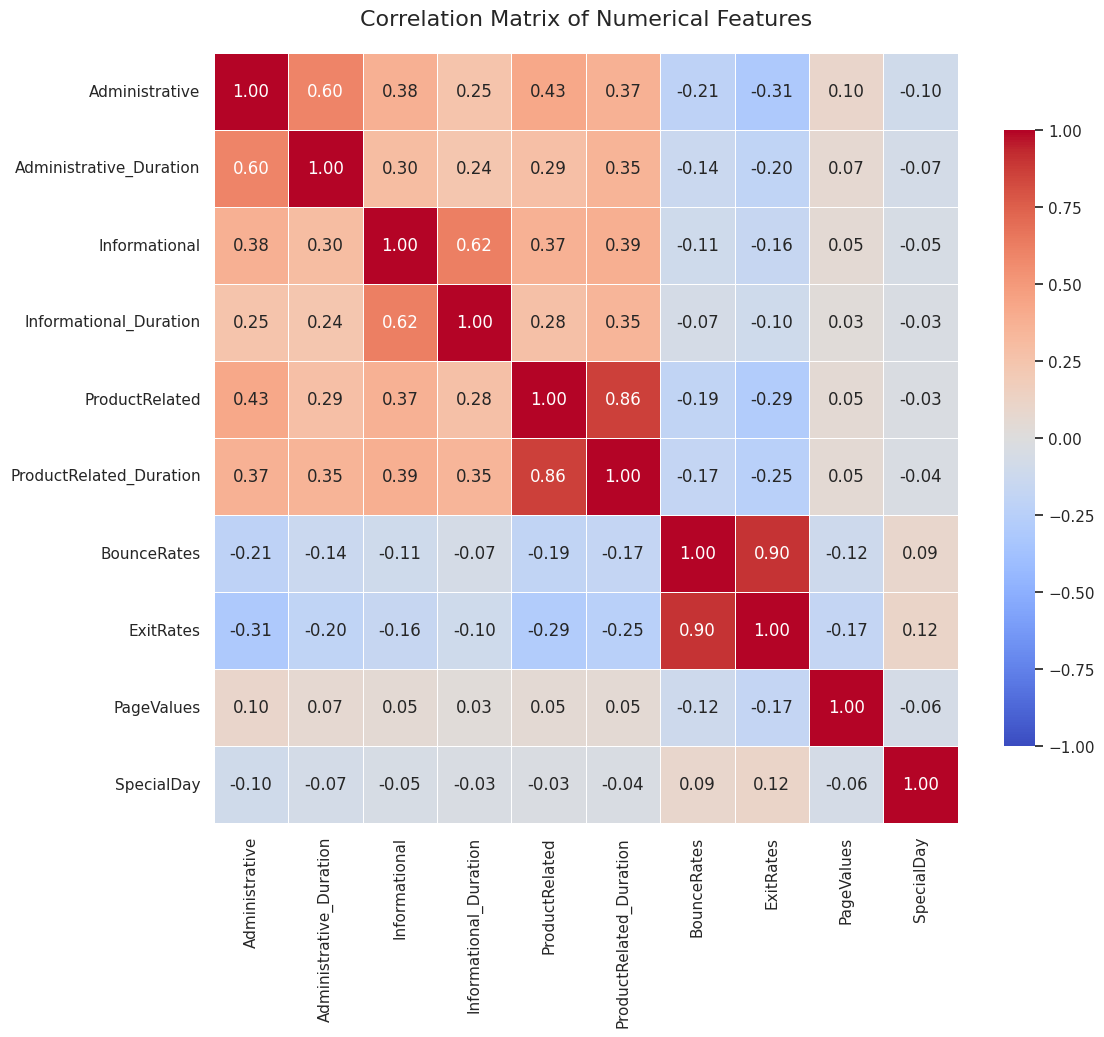

In [ ]:
# Safely select numerical columns and exclude the Target
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Numerical Features', fontsize=16, pad=20)
plt.show()


## Statistical Significance (P-Value Analysis)

Based on our correlation heatmap, we identified two highly correlated feature pairs:
- `BounceRates` and `ExitRates`
- `ProductRelated` and `ProductRelated_Duration`

To evaluate which feature from each pair maintains a stronger statistical relationship with our target variable (`Revenue`), we compute the Pearson Correlation coefficient and its associated p-value.

In statistical testing, a smaller p-value (closer to 0) indicates a highly significant effect. Therefore, for each pair, we will retain the feature with the lowest, most significant p-value.



In [ ]:
# 1. Define the pairs of features to investigate
dubious_pairs = [
    ('ProductRelated', 'ProductRelated_Duration'),
    ('BounceRates', 'ExitRates')
]

target_col = 'Revenue'

print(f"--- Correlation and P-Value Analysis with Target: '{target_col}' ---\n")

# 2. Loop to analyze and print the results
for feat1, feat2 in dubious_pairs:
    print(f"Analyzing Pair: [{feat1}] vs [{feat2}]")

    corr1, p_val1 = pearsonr(df[feat1], df[target_col])
    print(f"   > {feat1}:")
    print(f"     - Correlation: {corr1:.4f}")
    print(f"     - P-value:     {p_val1:.4e}")

    corr2, p_val2 = pearsonr(df[feat2], df[target_col])
    print(f"   > {feat2}:")
    print(f"     - Correlation: {corr2:.4f}")
    print(f"     - P-value:     {p_val2:.4e}")

    print("-" * 60)


--- Correlation and P-Value Analysis with Target: 'Revenue' ---

Analyzing Pair: [ProductRelated] vs [ProductRelated_Duration]
   > ProductRelated:
     - Correlation: 0.1560
     - P-value:     2.2083e-67
   > ProductRelated_Duration:
     - Correlation: 0.1501
     - P-value:     2.0686e-62
------------------------------------------------------------
Analyzing Pair: [BounceRates] vs [ExitRates]
   > BounceRates:
     - Correlation: -0.1451
     - P-value:     2.0740e-58
   > ExitRates:
     - Correlation: -0.2043
     - P-value:     3.5455e-115
------------------------------------------------------------


## Feature Selection (Handling Multicollinearity)

By analyzing the individual correlation and statistical significance (p-values) of our highly correlated pairs against the target variable, we can select which features to maintain and which to drop.

- **`BounceRates` vs `ExitRates`**

`ExitRates` shows a stronger negative correlation with `Revenue` (-0.2043) and an incredibly small, dominant p-value ($3.5455 \times 10^{-115}$) compared to `BounceRates` ($2.0740 \times 10^{-58}$).

We will **drop `BounceRates`** and **keep `ExitRates`**.

-  **`ProductRelated` vs `ProductRelated_Duration`**

`ProductRelated` achieves a slightly higher positive correlation (0.1560) and a smaller p-value ($2.2083 \times 10^{-67}$) than `ProductRelated_Duration` ($2.0686 \times 10^{-62}$).

We will **drop `ProductRelated_Duration`** and **keep `ProductRelated`**.

In [ ]:
# List of redundant columns to drop
columns_to_drop = ['BounceRates', 'ProductRelated_Duration']

# Drop the highly correlated features
df = df.drop(columns=columns_to_drop)
print(f"Dropped features: {columns_to_drop}\n")

# Re-calculate the list of numerical features to keep everything synced for the Pipeline
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

Dropped features: ['BounceRates', 'ProductRelated_Duration']



# 5. Saving the new Dataset

In [ ]:
df.to_csv('/content/drive/MyDrive/DMML_Project/online_shoppers_cleaned.csv', index=False)

print(f"Dataset saved successfully'")
print(f"Dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset saved successfully'
Dimensions: 12205 rows and 16 columns.

